# Customer Churn Prediction — End-to-End Starter Notebook

This notebook is designed to align with the project phases and produce portfolio-ready outputs.

## 1) Business Objective
- Predict likely churners.
- Simulate targeted retention to estimate net financial benefit.
- Primary metric: ROC-AUC; deployment threshold tuned for business trade-off.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(str(Path('../src').resolve()))
from churn_prediction.pipeline import run_training_pipeline

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 200)

## 2) Load Data

In [2]:
DATA_PATH = Path('../data/raw/customer_churn.csv')

if not DATA_PATH.exists():
    print(f'Place your dataset at: {DATA_PATH.resolve()}')
else:
    df = pd.read_csv(DATA_PATH)
    print(df.shape)
    display(df.head())

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 3) Quick EDA Checks

In [6]:
if 'df' in globals():
    print('Missing values (top 15):')
    display(df.isna().sum().sort_values(ascending=False).head(15))

    

    display(df.describe(include='all').transpose().head(20))

Missing values (top 15):


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
dtype: int64

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,3186-AJIEK,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4) Baseline Training + Evaluation + Business Simulation

In [4]:
if DATA_PATH.exists():
    results = run_training_pipeline(str(DATA_PATH))
    results

## 5) Compare Model Metrics

,roc_auc,precision,recall,f1
xgboost,0.842391,0.655405,0.518717,0.579104
logistic_regression,0.840146,0.535857,0.719251,0.614155
random_forest,0.826391,0.621951,0.545455,0.581197


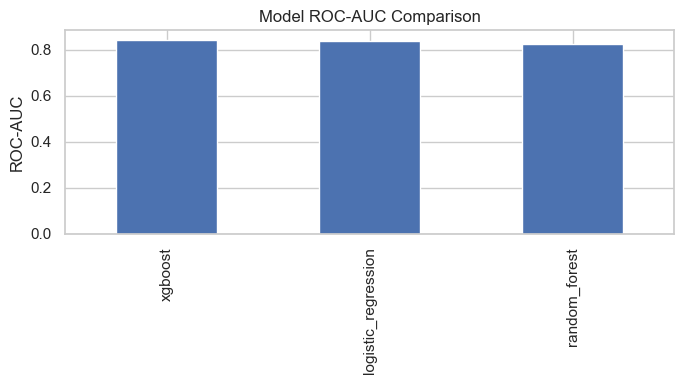

In [5]:
if 'results' in globals():
    metrics_df = pd.DataFrame(results['benchmark_results']).T.sort_values('roc_auc', ascending=False)
    display(metrics_df)

    ax = metrics_df['roc_auc'].plot(kind='bar', figsize=(7, 4), title='Model ROC-AUC Comparison')
    ax.set_ylabel('ROC-AUC')
    plt.tight_layout()
    plt.show()

## 6) Threshold & Business Impact Summary

In [6]:
if 'results' in globals():
    print('Best model:', results['best_model'])
    print('Optimal threshold:', round(results['optimal_threshold'], 3))
    print('Tuned metrics:')
    display(pd.Series(results['tuned_metrics'], name='value'))

    print('Business impact:')
    display(pd.Series(results['business_impact'], name='value'))

Best model: xgboost
Optimal threshold: 0.1
Tuned metrics:


roc_auc      0.842391
precision    0.417857
recall       0.938503
f1           0.578254
Name: value, dtype: float64

Business impact:


n_targeted                          281.0
correctly_identified_churners       188.0
retention_cost_total              14050.0
revenue_saved                    150400.0
net_benefit                      136350.0
Name: value, dtype: float64